# COVID-19 in Newfoundland and Labrador

This [Jupyter Lab](https://jupyter.org/) notebook analyzes a data set on COVID-19 cases in Canada. The intention is to test the effectiveness of the [Gompertz function](https://en.wikipedia.org/wiki/Gompertz_function) in describing and predicting the total number of COVID-19 cases, specifically in Newfoundland and Labrador.

## Introduction

The **Gompertz function** is defined by Wikipedia as, "a sigmoid function which describes growth as being slowest at the start and end of a given time period." It is commonly used in modelling many forms of biological growth, including the growth of animals and plants in size, the growth of tumour cells in the body and so on. Can the Gompertz function also describe and predict the growth of COVID-19?

To answer this question, we will create a model centered around the Gompertz function, using it to fit a curve to a record of the total number of COVID-19 cases in the province. From evaluating the accuracy of the results, we should be able to get a good impression of the effectiveness of the Gompertz function in modelling the growth of the pandemic.

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime
import numpy as np
import math
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

data = pd.read_csv("https://health-infobase.canada.ca/src/data/covidLive/covid19-download.csv")
# Convert totalcases to a number, eliminating any NA results created in the process.
data['totalcases'] = pd.to_numeric(data['totalcases'],errors="coerce")
data = data.dropna(subset='totalcases')
# Convert date from a string into a proper datetime.
data['date'] = pd.to_datetime(data['date'])
# Narrow the data set down to fields relevant to Newfoundland and Labrador.
data = data[data['prname'] == "Newfoundland and Labrador"]
# To avoid instances of division by zero, we'll only consider case numbers
# greater than zero.
data = data[data['totalcases'] != 0]

Now that the basic data tidying is complete, it's possible to proceed with defining the Gompertz function itself. A **training** and **test** data set will also be created by partitioning the original data set; 80% of the records will be used for training the model and the remaining 20% will be used to test its effectiveness.

In [133]:
# Define the Gompertz function.
def gompertz(x, A, B, C):
    return A * np.exp(-B * np.exp(-C * x))

# Split the data into two groups, 80% of which will be used for training the
# model and 20% of which will be used for testing its effectiveness.
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

# Split into X and y for both training and testing sets.
X_train = train_data.drop('totalcases', axis=1)
y_train = train_data['totalcases']
X_test = test_data.drop('totalcases', axis=1)
y_test = test_data['totalcases']

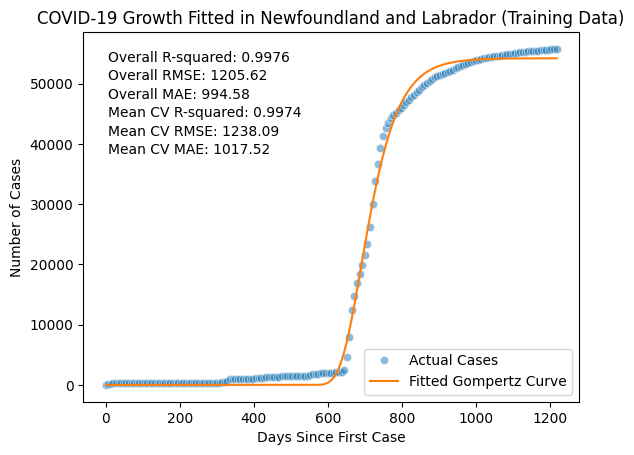

In [134]:
# Calculate 'days' column for training data.
X_train['days'] = (X_train['date'] - X_train['date'].min()).dt.days

# Initial guesses for Gompertz curve parameters.
initial_guess = [y_train.max(), 1, 0.01]

# Perform K-Fold cross-validation.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []
cv_mae_scores = []

for train_index, test_index in kf.split(X_train):
    train_days, test_days = X_train['days'].iloc[train_index], X_train['days'].iloc[test_index]
    train_cases, test_cases = y_train.iloc[train_index], y_train.iloc[test_index]

    try:
        # Fit the Gompertz curve to the training fold.
        params, covariance = curve_fit(gompertz, train_days, train_cases, p0=initial_guess, maxfev=10000)
        
        # Predict on the test fold.
        predicted_cases = gompertz(test_days, *params)
        
        # Calculate R-squared, RMSE, and MAE for the test fold.
        residuals = test_cases - predicted_cases
        ss_total = np.sum((test_cases - np.mean(test_cases)) ** 2)
        ss_residual = np.sum(residuals ** 2)
        r_squared = 1 - (ss_residual / ss_total)
        rmse = np.sqrt(mean_squared_error(test_cases, predicted_cases))
        mae = mean_absolute_error(test_cases, predicted_cases)
        
        # Append metrics to the lists.
        cv_r2_scores.append(r_squared)
        cv_rmse_scores.append(rmse)
        cv_mae_scores.append(mae)
    
    except RuntimeError:
        print("Curve fitting failed for this fold")
        continue

# Calculate mean cross-validation metrics.
mean_cv_r2 = np.mean(cv_r2_scores)
mean_cv_rmse = np.mean(cv_rmse_scores)
mean_cv_mae = np.mean(cv_mae_scores)

# Fit the Gompertz curve to the full training data.
params, covariance = curve_fit(gompertz, X_train['days'], y_train, p0=initial_guess, maxfev=10000)
X_train['fitted_cases'] = gompertz(X_train['days'], *params)

# Calculate residuals for the full training data.
residuals = y_train - X_train['fitted_cases']

# Calculate R-squared for the full training data.
ss_total = np.sum((y_train - np.mean(y_train))**2)
ss_residual = np.sum(residuals**2)
r_squared = 1 - (ss_residual / ss_total)

# Calculate RMSE and MAE for the full training data.
rmse = np.sqrt(mean_squared_error(y_train, X_train['fitted_cases']))
mae = mean_absolute_error(y_train, X_train['fitted_cases'])


# Actual cases.
sns.lineplot(x=X_train['days'], y=y_train, label='Actual Cases', color='tab:blue', marker='o', linestyle='None', alpha=0.5)

# Fitted Gompertz curve
sns.lineplot(x=X_train['days'], y=X_train['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')

plt.title("COVID-19 Growth Fitted in Newfoundland and Labrador (Training Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)

# Display performance metrics directly on the plot.
plt.text(0.05, 0.95, f"Overall R-squared: {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"Overall RMSE: {rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.85, f"Overall MAE: {mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.80, f"Mean CV R-squared: {mean_cv_r2:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.75, f"Mean CV RMSE: {mean_cv_rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.70, f"Mean CV MAE: {mean_cv_mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.show()




The model has been trained using a subset of the original data set. We can now evaluate its performance against the test data set.

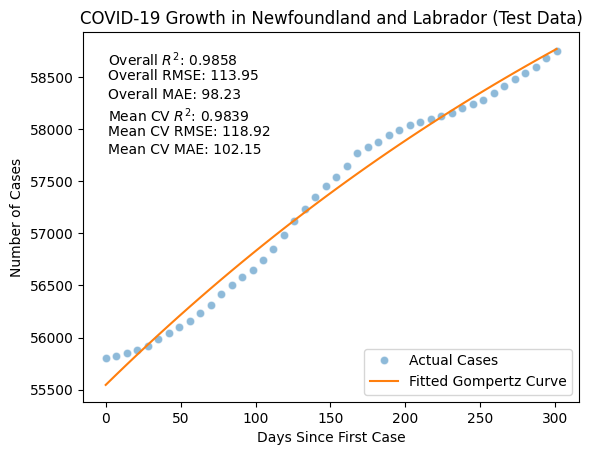

In [135]:
X_test['days'] = (X_test['date'] - X_test['date'].min()).dt.days

initial_guess = [y_test.max(), 1, 0.01]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []
cv_mae_scores = []

for train_index, test_index in kf.split(X_test):
    train_days, test_days = X_test['days'].iloc[train_index], X_test['days'].iloc[test_index]
    train_cases, test_cases = y_test.iloc[train_index], y_test.iloc[test_index]

    try:
        params, covariance = curve_fit(gompertz, train_days, train_cases, p0=initial_guess, maxfev=10000)
        
        predicted_cases = gompertz(test_days, *params)
        
        residuals = test_cases - predicted_cases
        ss_total = np.sum((test_cases - np.mean(test_cases)) ** 2)
        ss_residual = np.sum(residuals ** 2)
        r_squared = 1 - (ss_residual / ss_total)
        rmse = np.sqrt(mean_squared_error(test_cases, predicted_cases))
        mae = mean_absolute_error(test_cases, predicted_cases)
        
        cv_r2_scores.append(r_squared)
        cv_rmse_scores.append(rmse)
        cv_mae_scores.append(mae)
    
    except RuntimeError:
        print("Curve fitting failed for this fold")
        continue

mean_cv_r2 = np.mean(cv_r2_scores)
mean_cv_rmse = np.mean(cv_rmse_scores)
mean_cv_mae = np.mean(cv_mae_scores)

params, covariance = curve_fit(gompertz, X_test['days'], y_test, p0=initial_guess, maxfev=10000)
X_test['fitted_cases'] = gompertz(X_test['days'], *params)

residuals = y_test - X_test['fitted_cases']

ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_residual = np.sum(residuals**2)
r_squared = 1 - (ss_residual / ss_total)

rmse = np.sqrt(mean_squared_error(y_test, X_test['fitted_cases']))
mae = mean_absolute_error(y_test, X_test['fitted_cases'])

sns.lineplot(x=X_test['days'], y=y_test, label='Actual Cases', color='tab:blue', marker='o', linestyle='None', alpha=0.5)
sns.lineplot(x=X_test['days'], y=X_test['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')

plt.title("COVID-19 Growth in Newfoundland and Labrador (Test Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)

plt.text(0.05, 0.95, f"Overall $R^2$: {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"Overall RMSE: {rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.85, f"Overall MAE: {mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.80, f"Mean CV $R^2$: {mean_cv_r2:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.75, f"Mean CV RMSE: {mean_cv_rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.70, f"Mean CV MAE: {mean_cv_mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.show()




The model appears to perform reasonably well against the test data set as well. We are now ready to apply the model to the entirety of the data set.

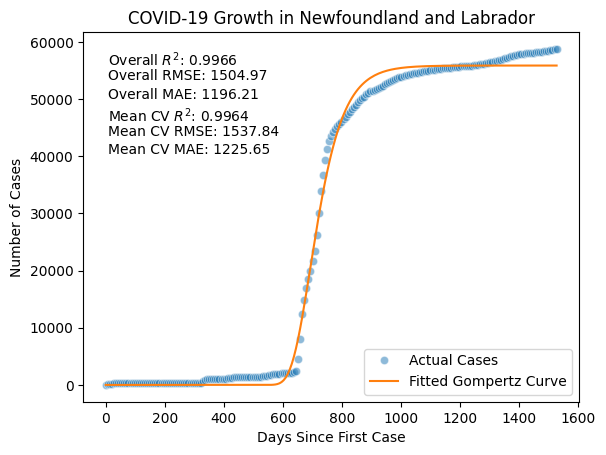

In [140]:
data['days'] = (data['date'] - data['date'].min()).dt.days

initial_guess = [data['totalcases'].max(), 1, 0.01]

# Define parameter bounds to prevent overflow.
parameter_bounds = (
    [0, 0, 0],  # Lower bounds: A, B, C >= 0.
    [np.inf, np.inf, 1]  # Upper bounds: A, B unbounded, C <= 1.
)

# Perform K-fold cross-validation.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []
cv_mae_scores = []

for train_index, test_index in kf.split(data):
    train_data = data.iloc[train_index]
    test_data = data.iloc[test_index].copy()  # Explicitly create a copy to avoid SettingWithCopyWarning.

    try:
        # Fit the Gompertz curve to the training data.
        params, covariance = curve_fit(
            gompertz, 
            train_data['days'], 
            train_data['totalcases'], 
            p0=initial_guess, 
            bounds=parameter_bounds, # The parameter bounds are added here.
            maxfev=10000
        )
        
        # Generate some predictions on the test data.
        test_data['fitted_cases'] = gompertz(test_data['days'], *params)
        
        # Calculate the residuals.
        residuals = test_data['totalcases'] - test_data['fitted_cases']

        # Calculate performance metrics.
        ss_total = np.sum((test_data['totalcases'] - np.mean(test_data['totalcases'])) ** 2)
        ss_residual = np.sum(residuals ** 2)
        r_squared = 1 - (ss_residual / ss_total)
        rmse = np.sqrt(mean_squared_error(test_data['totalcases'], test_data['fitted_cases']))
        mae = mean_absolute_error(test_data['totalcases'], test_data['fitted_cases'])

        # Append metrics to the lists.
        cv_r2_scores.append(r_squared)
        cv_rmse_scores.append(rmse)
        cv_mae_scores.append(mae)
    
    except RuntimeError:
        print("Curve fitting failed for this fold")
        continue

# Calculate mean cross-validation metrics.
mean_cv_r2 = np.mean(cv_r2_scores)
mean_cv_rmse = np.mean(cv_rmse_scores)
mean_cv_mae = np.mean(cv_mae_scores)

# Fit the Gompertz curve to the entire dataset.
params, covariance = curve_fit(
    gompertz, 
    data['days'], 
    data['totalcases'], 
    p0=initial_guess, 
    bounds=parameter_bounds,
    maxfev=10000
)
data['fitted_cases'] = gompertz(data['days'], *params)

# Calculate the residuals for the full dataset.
residuals = data['totalcases'] - data['fitted_cases']

# Calculate R-squared.
ss_total = np.sum((data['totalcases'] - np.mean(data['totalcases'])) ** 2)
ss_residual = np.sum(residuals ** 2)
r_squared = 1 - (ss_residual / ss_total)

# Calculate RMSE and MAE.
rmse = np.sqrt(mean_squared_error(data['totalcases'], data['fitted_cases']))
mae = mean_absolute_error(data['totalcases'], data['fitted_cases'])

# Plot of the actual case numbers.
sns.lineplot(x=data['days'], y=data['totalcases'], label='Actual Cases', color='tab:blue', marker='o', linestyle='None', alpha=0.5)

# Plot of the fitted Gompertz curve.
sns.lineplot(x=data['days'], y=data['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')

plt.title("COVID-19 Growth in Newfoundland and Labrador")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)

# Display performance metrics directly on the plot.
plt.text(0.05, 0.95, f"Overall $R^2$: {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"Overall RMSE: {rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.85, f"Overall MAE: {mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.80, f"Mean CV $R^2$: {mean_cv_r2:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.75, f"Mean CV RMSE: {mean_cv_rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.70, f"Mean CV MAE: {mean_cv_mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.show()


## Analysis

### Summary Statistics

In this case, the high overall $R^2$ value indicates that the model provides a very good fit for the data. The overall RMSE, or the average deviation in predicted values from the observed values (in terms of cases) is low when compared to the scale of total COVID-19 cases, as is the MAE (absolute error). A high Mean Cross-Validation $R^2$ help to confirm the robustness of the model. Finally, the mean CV RMSE and mean CV MAE are very close in values to the overall RMSE and MAE. This indicates consistent and reliable performance across subsets of the data.

### Residuals Plot

We can further examine the performance of the model by examining a plot of the residuals.

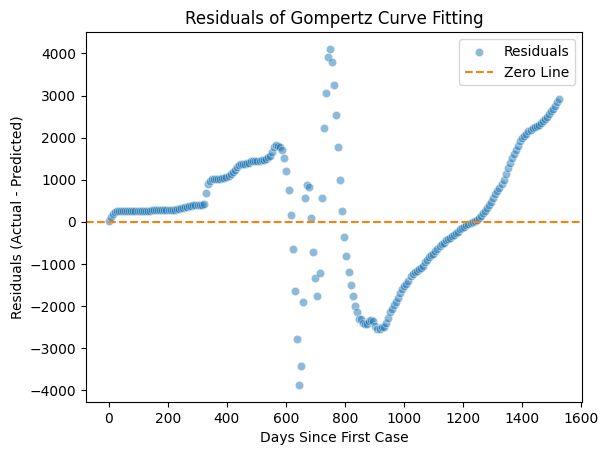

In [137]:
# Assuming you already have the Gompertz fitted values stored in 'X_train['fitted_cases']'
# Calculate the residuals
residuals = data['totalcases'] - data['fitted_cases']

# Plot the residuals
sns.scatterplot(x=data['days'], y=residuals, color='tab:blue', label='Residuals',alpha=0.5)
plt.axhline(y=0, color='tab:orange', linestyle='--', label='Zero Line')  # Zero line reference
plt.title("Residuals of Gompertz Curve Fitting")
plt.xlabel("Days Since First Case")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(False)
plt.show()


There are clearly systematic patterns in the residuals plot. There are noticeable trends and deviations which suggest that the model does not fully capture certain aspects of the data. From days 0 to about 600, the residuals exhibit an upward trend, indicating **underestimation** in the model. In contrast, after about 800 days the residuals show a downward trend followed by an upward curve, indicating first **overestimation** and then **underestimation** during this time period. Days 600 to 800 shows widely scattered residuals, indicating a **poor fit** during that period.

There is a considerable variation in the spread of the residuals over time. The residuals plot begins with the residuals clustered quite close to zero, but during the period spanning from days 600 to 800, the residuals are widely scattered. There is clearly a **widening** pattern in the residuals after about day 1000. This variation indicates **heteroscedasticity,** in which the variance of the errors change over time.

### Can we improve upon the model?

One way we could potentially address the issue of heteroscedasticity would be to try different transformations of the dependent variable (the total number of cases), in an attempt to determine if one such transformation would result in a better fit for the data. For example, here is a plot of the same data and the same fitted curve, but with a square root transformation applied to the dependent variable.

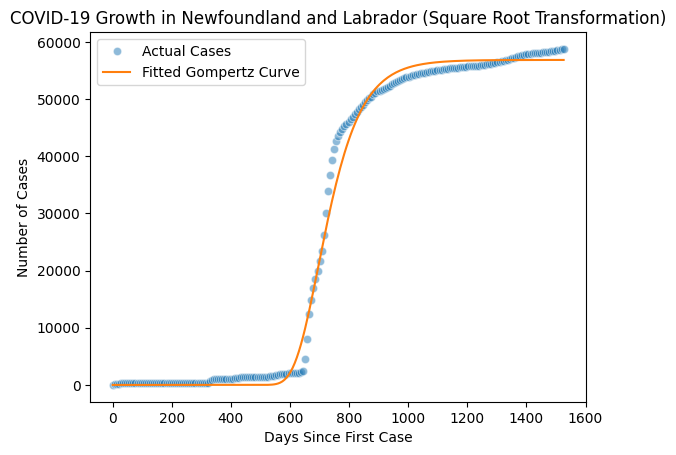

In [138]:
# Perform a square root transformation on the dependent variable.
data['sqrt_totalcases'] = np.sqrt(data['totalcases'])

data['days'] = (data['date'] - data['date'].min()).dt.days

initial_guess = [np.sqrt(data['totalcases'].max()), 1, 0.01]

params, covariance = curve_fit(gompertz, data['days'], data['sqrt_totalcases'], p0=initial_guess)

# Generate fitted values, then back-transform them.
data['fitted_sqrt_cases'] = gompertz(data['days'], *params)
data['fitted_cases'] = data['fitted_sqrt_cases']**2

data['residuals'] = data['totalcases'] - data['fitted_cases']

# Calculate summary statistics.
ss_total = np.sum((data['totalcases'] - np.mean(data['totalcases']))**2)
ss_residual = np.sum(residuals**2)
r_squared = 1 - (ss_residual / ss_total)
rmse = np.sqrt(mean_squared_error(data['totalcases'], data['fitted_cases']))
mae = mean_absolute_error(data['totalcases'], data['fitted_cases'])

sns.lineplot(x=data['days'], y=data['totalcases'], label='Actual Cases', color='tab:blue', marker='o', linestyle='None', alpha=0.5)
sns.lineplot(x=data['days'], y=data['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')
plt.title("COVID-19 Growth in Newfoundland and Labrador (Square Root Transformation)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)
plt.show()



We can examine the effects of the transformation by plotting the residuals again.

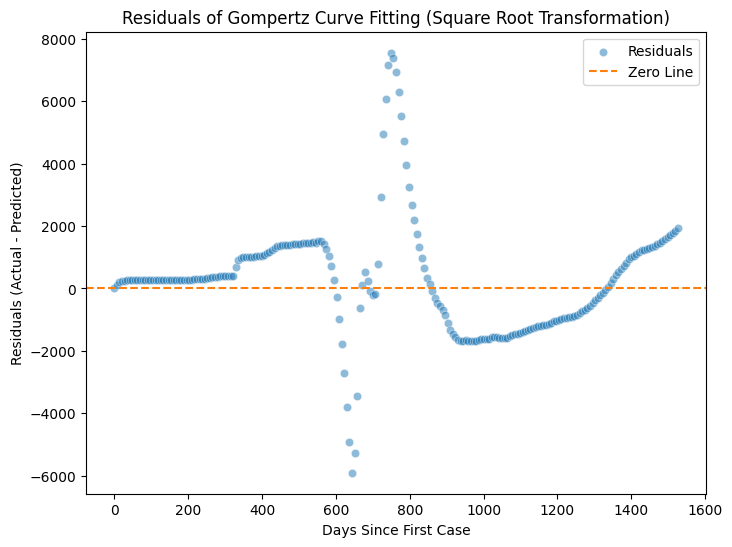

In [139]:
# Residual Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['days'], y=data['residuals'], color='tab:blue', label='Residuals',alpha=0.5)
plt.axhline(0, color='tab:orange', linestyle='--', label='Zero Line')
plt.title("Residuals of Gompertz Curve Fitting (Square Root Transformation)")
plt.xlabel("Days Since First Case")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(False)
plt.show()

This time there is an even wider spread of the residuals across the zero line. We can conclude that the square root transformation does **not** improve the accuracy of the model.

## Conclusion

Does the Gompertz model provide an adequate basis upon which the total number of COVID-19 cases can be described and predicted? While the curve fitting from such a model produces impressive results, the summary statistics collected, as well as the residual plots, make it clear that such an approach is not sufficient in describing and predicting the progression of the pandemic.

The weaknesses of the Gompertz model can be summarized as follows:

- The Gompertz model assumes a fixed asymptote or maximum limit, $A$, for the total number of cases. This represents the "saturation point." In truth, the maximum number of cases can be influenced by any number of external factors, such as the emergence of new variants and public health interventions. As a result, the model may over- or under-predict cases when these factors are involved.
- The model lacks flexibility for the multiple waves in which COVID-19 outbreaks occur. The model is essentialy designed to describe a **single** wave of growth with a sigmoidal shape. COVID-19 outbreaks occur in **multiple** waves, due to the emergence of new variants, seasonal effects, policy changes and other factors.
- The model assumes that growth dynamics are determined entirely by internal factors, such as the spread of the disease and natural limits on that spread. The Gompertz model does not account for numerous external factors that influence the real-world dynamics of any pandemic, such as changes in social behaviour, government interventions and variability in transmission rates.
- The model may struggle to f it the early exponential phase of a pandemic, where case numbers are rising rapidly, due to its growth rate not being purely exponential. In addition, during the late stages as cases begin to plateau, deviations from the predicted curve can often occur, due to such factors as lingering or sporadic outbreaks or incomplete saturation.
- High-quality, complete data that is noise free is ideal for ensuring the performance of the model. Unfortunately, COVID-19 data often contain inaccuracies or missing information, such as underrreporting of cases, delays in reporting, even regional differences in data collection. All of these issues can lead to unreliable parameter estimates and ultimately, poor predictive power.
- The Gompertz model assumes a **homogenous** population, where all individuals have an equal susceptibility and exposure. Of course in reality, any given population will be **heterogeneous,** with different subgroups within that pooulation having different risks of infection.
- The model fails to capture external interventions, making the assumption that growth dynamics are determined solely by the natural progresion of the disease. This makes its predictions less reliable during phases of the pandemic where significant intervention impacts occurred.
- The model often lacks built-in mechamisms to quantify uncertainty or provide confidence intervals. This makes it more difficult to assess the reliability of predictions, particularly in the long-term.

It remains to be seen what the final financial impact of COVID-19 will be. In the case of Newfoundland and Labrador, we can see that it took nearly **1200** days before case numbers began to level off. During that time, strict quarantine measures were enforced in the province, the effects of which were felt by a myriad of local businesses that were forced to shut down. In such an uncertain environment and with difficulty finding the labour to fill positions, many such businesses were forced to close their doors, not knowing if or when the pandemic would ever truly end.

Modelling can provide potential answers to many questions about the spread of a disease or epidemic, but **only** if the right choice of model is selected and properly evaluated. The Gompertz model provides an adequate basis upon which to model the spread of COVID-19 with very limited information; it was one of the few models that **could** be applied to the data set used in this study. In reality, the Gompertz model is never used alone in analyzing the progression of COVID-19, but in conjunction with other epidemiological models that take into consideration susceptibility, infection rates, deaths and other factors. All of these can help improve the efficacy of the model in terms of describing and predicting the progression of the pandemic. Nonetheless, it has been suitably demonstrated that that Gompertz model provides adequate results even when such information is limited or incomplete, despite it sensitivity to data quality.

## Acknowledgements

This notebook was authored with significant assistance from [ChatGPT.](https://chatgpt.com) I do not have a strong background in mathematics or statistics; as such, I rely on reading research papers, journals and websites on the subjects, in order to try and form as accurate a picture of the details as possible. ChatGPT provided an invaluable resource in describing and explaining the statistics and the processes involved in modelling. In addition, it accurately diagnosed (and fixed) a pair of bugs that I was unable to find a solution for on my own. My thanks to **OpenAI** for making such a great tool freely available online.